# Proyecto Moduolo 7: Segmentador inteligente de clientes minoristas.

### 1. Fundamentos del Aprendizaje No Supervisado

El aprendizaje no supervisado se caracteriza por trabajar con datos **no etiquetados** para descubrir patrones, relaciones y estructuras ocultas sin intervención humana directa. 

A diferencia del aprendizaje supervisado, donde entrenamos modelos con una "verdad conocida" (por ejemplo, predecir el gasto anual exacto de un cliente basándonos en datos históricos), el aprendizaje no supervisado intenta comprender la organización interna de los datos por sí mismo. No hay una variable objetivo a predecir; el foco está en la exploración y agrupación natural de la información.

In [1]:
# 1. Importación de librerías y configuración del entorno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para que los gráficos del notebook luzcan profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Mensaje de validación
print("Librerías importadas y entorno configurado correctamente.")

# Descargado el dataset CSV desde Kaggle, incorporado el archivo al entorno de Colab.
dataset_path = 'test.csv'

try:
    # Cargar los datos 
    df = pd.read_csv(dataset_path)
    print("Dataset cargado exitosamente. Dimensiones:", df.shape)
    
    # Mostrar las primeras filas para una inspección inicial de los datos
    display(df.head())
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{dataset_path}'.")
    print("Por favor, descarga el archivo de Kaggle y colócalo en la misma carpeta que este notebook.")

Librerías importadas y entorno configurado correctamente.
Dataset cargado exitosamente. Dimensiones: (2627, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6,A


### 2. Técnicas de Clusterización

La **clusterización** es una técnica de análisis exploratorio que agrupa objetos de tal manera que los elementos dentro de un mismo clúster sean más similares entre sí que con los de otros grupos. Su valor principal radica en descubrir estructuras y patrones ocultos sin necesidad de etiquetas predefinidas[cite: 42].

#### Aplicaciones Profesionales
Esta técnica es versátil y se aplica en diversos dominios:
* **Marketing:** Segmentación de consumidores según patrones de compra.
* **Detección de Anomalías:** Identificación de fraudes o fallos en sistemas (objetos que no encajan en ningún clúster).
* **Biología y Medicina:** Agrupamiento de genes o clasificación de pacientes según síntomas.
* **Procesamiento de Lenguaje Natural:** Agrupación de documentos o noticias por temáticas.

### 2.1 Principales Algoritmos de Clusterización

Para este proyecto, evaluaremos los siguientes algoritmos según su eficiencia y la naturaleza de nuestros datos:

| Algoritmo | Ventajas | Desventajas |
| :--- | :--- | :--- |
| **K-Means** | Rápido, eficiente y fácil de interpretar. | Requiere definir $K$ previamente y es sensible a outliers. |
| **Jerárquico** | No necesita definir $K$ a priori; genera dendrogramas visuales. | Poco escalable para datasets muy grandes. |
| **DBSCAN** | Detecta formas arbitrarias e ignora outliers (ruido). | No funciona bien con densidades muy variables. |
| **Mezcla Gaussiana** | Mayor flexibilidad; asignación probabilística de clústeres. | Complejo de parametrizar y sensible a la inicialización. |

Datos preprocesados y escalados con StandardScaler.
Forma de la matriz resultante: (2267, 4)


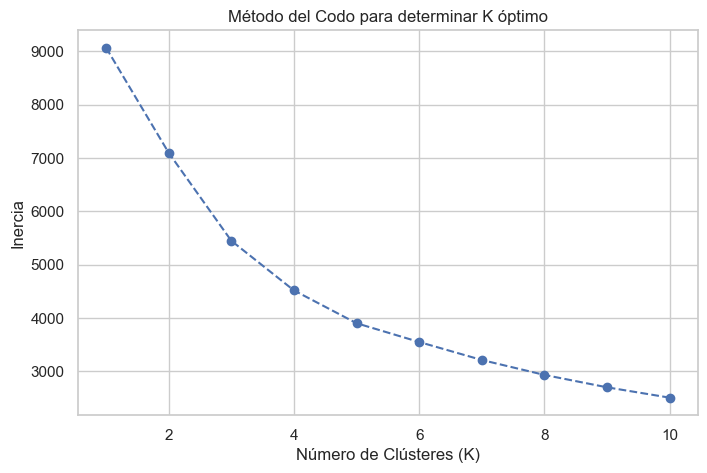

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Seleccionamos solo las variables numéricas relevantes para la segmentación
# Ejemplo: 'Age', 'Work_Experience', 'Spending Score'
numeric_cols = df.select_dtypes(include=[np.number]).columns
data_to_scale = df[numeric_cols].dropna()

# Se deben escalar los datos, dado que K-Means se basa en distancias euclidianas.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_to_scale)

print("Datos preprocesados y escalados con StandardScaler.")
print(f"Forma de la matriz resultante: {data_scaled.shape}")

# Determinación del número óptimo de clústeres (Método del Codo)
inercia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(data_scaled)
    inercia.append(model.inertia_)

# Visualización del Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para determinar K óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.show()

### 3. Reducción de Dimensionalidad

La reducción de dimensionalidad consiste en transformar un conjunto de datos con muchas variables en una representación de menor dimensión sin perder información significativa. 

### Beneficios Clave:
* **Eficiencia:** Mejora el rendimiento computacional de los modelos.
* **Visualización:** Permite representar datos complejos en gráficas de 2D o 3D.
* **Generalización:** Ayuda a evitar el sobreajuste (overfitting) al eliminar ruido y redundancias.

### Estrategias de Extracción de Características:
Nos centraremos en dos algoritmos fundamentales: **PCA** (lineal) y **t-SNE** (no lineal).

### 3.1 Comparativa Técnica: PCA vs. t-SNE

| Característica | PCA (Principal Component Analysis) | t-SNE (t-distributed Stochastic Neighbor Embedding) |
| :--- | :--- | :--- |
| **Tipo** | Lineal | No lineal |
| **Velocidad** | Alta | Media a Baja |
| **Estructura** | Preserva la estructura **Global** | Preserva la estructura **Local** (agrupamientos) |
| **Uso común** | Preprocesamiento y limpieza | Visualización de clústeres complejos |
| **Interpretación**| Alta (Varianza explicada) | Baja (Depende de hiperparámetros) |

Varianza explicada por PC1: 32.76%
Varianza explicada por PC2: 26.87%
Varianza total explicada: 59.64%


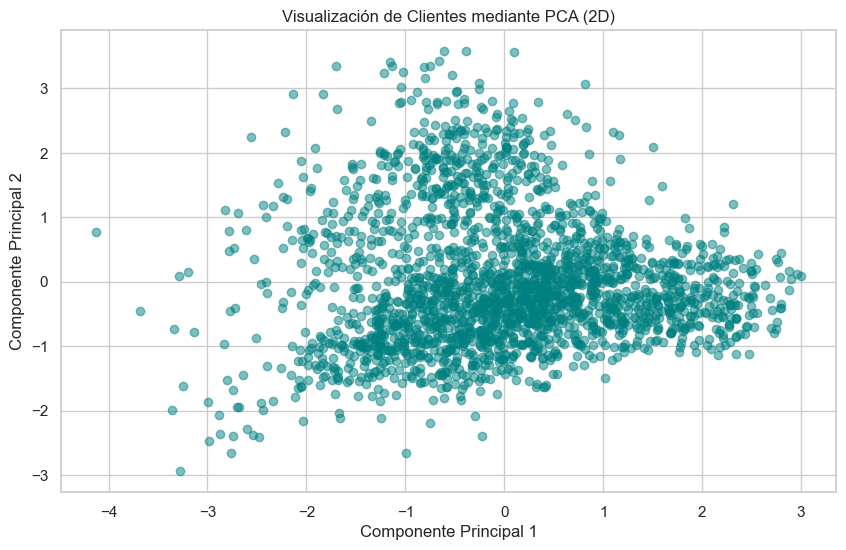

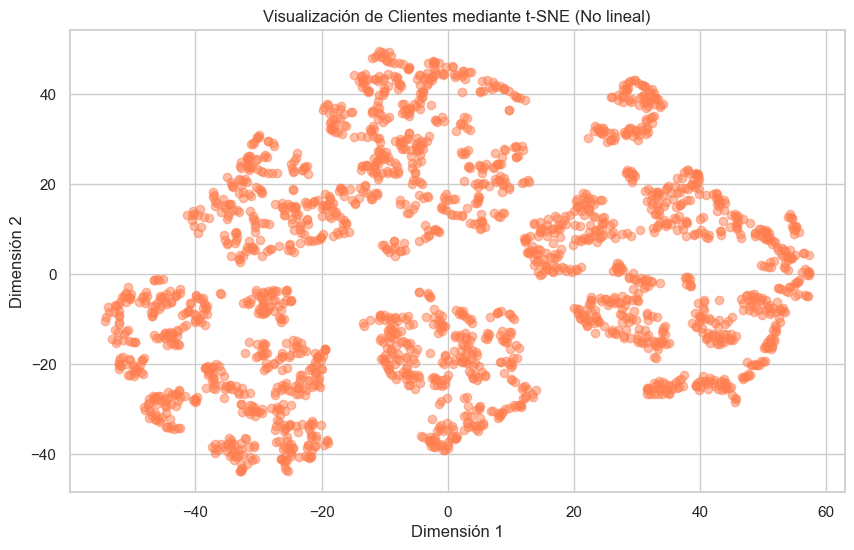

In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Aplicamos PCA para reducir a 2 componentes principales
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)

# Creamos un DataFrame con los resultados de PCA
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])

# Calculamos la varianza explicada
varianza_expl = pca.explained_variance_ratio_

print(f"Varianza explicada por PC1: {varianza_expl[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza_expl[1]:.2%}")
print(f"Varianza total explicada: {sum(varianza_expl):.2%}")

# Visualización rápida de PCA
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, c='teal')
plt.title('Visualización de Clientes mediante PCA (2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Aplicamos t-SNE (Usamos una perplejidad estándar de 30)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_data = tsne.fit_transform(data_scaled)

# Creamos un DataFrame con los resultados de t-SNE
df_tsne = pd.DataFrame(data=tsne_data, columns=['Dim 1', 'Dim 2'])

# Visualización de t-SNE
plt.scatter(df_tsne['Dim 1'], df_tsne['Dim 2'], alpha=0.5, c='coral')
plt.title('Visualización de Clientes mediante t-SNE (No lineal)')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.show()

> **Nota técnica:** Mientras que **PCA** es excelente para reducir el ruido antes de entrenar otros modelos, **t-SNE** será nuestra herramienta principal para presentar los clústeres finales a los interesados de la empresa, ya que tiende a separar mejor los grupos visualmente en espacios reducidos.

### 4. Implementación de Algoritmos de Clusterización

En esta etapa, aplicaremos los tres algoritmos fundamentales estudiados para identificar cuál se ajusta mejor a la estructura de nuestros datos de clientes:

1. **K-Means:** Basado en centroides. Buscaremos el número óptimo de grupos mediante el Método del Codo y el Coeficiente de Silueta.
2. **Agrupamiento Jerárquico:** Utilizaremos un dendrograma para visualizar la genealogía de los grupos.
3. **DBSCAN:** Basado en densidad. Ideal para detectar clientes con comportamientos atípicos (outliers/ruido).

### Métricas de Evaluación:
* **Inercia:** Suma de las distancias al cuadrado dentro de los clústeres.
* **Coeficiente de Silueta:** Mide qué tan similar es un objeto a su propio clúster en comparación con otros. Un valor cercano a 1 indica una excelente agrupación.

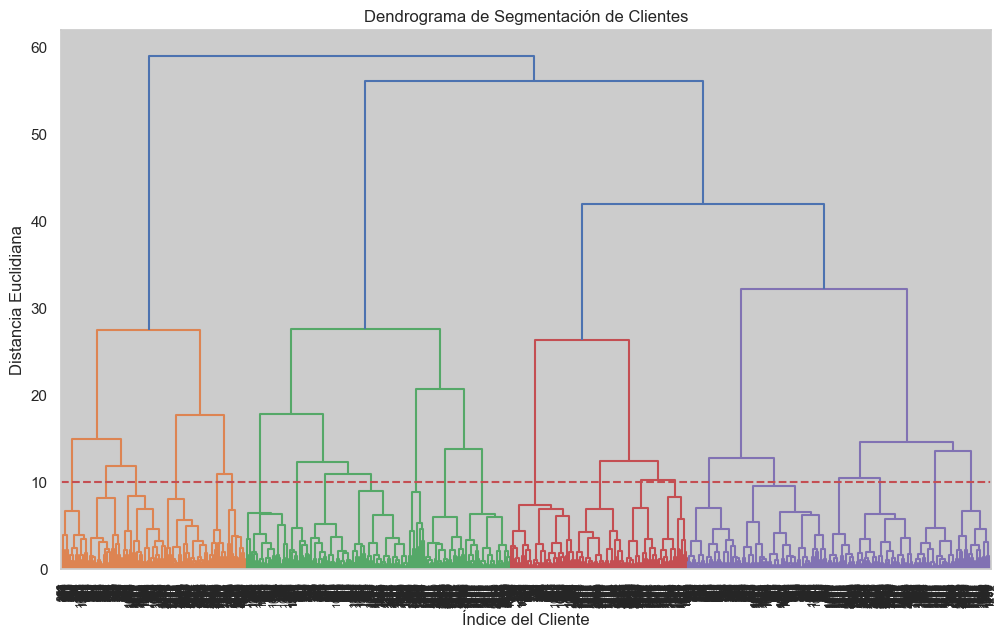

Configuración final: K = 5
Coeficiente de Silueta: 0.2480
Puntos identificados como ruido (Outliers): 344


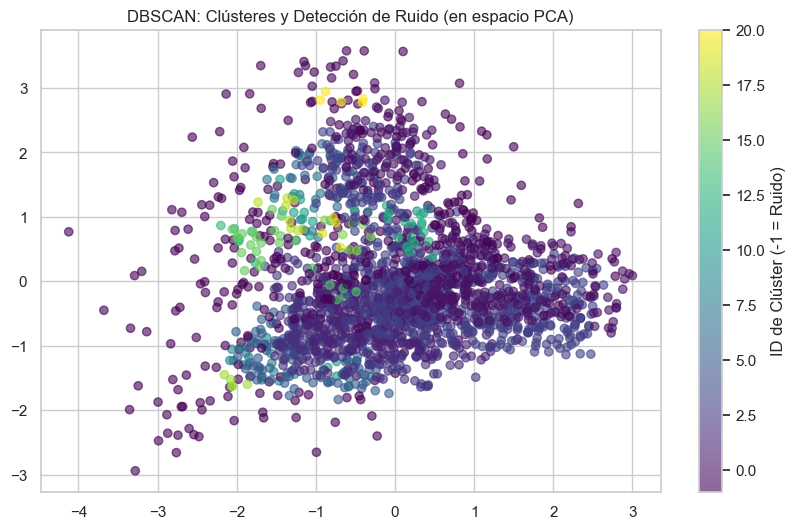

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df_final = df.dropna(subset=numeric_cols).copy()

# Generamos la matriz de enlace usando el método 'ward'
Z = linkage(data_scaled, method='ward')
plt.figure(figsize=(12, 7))
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
plt.title("Dendrograma de Segmentación de Clientes")
plt.xlabel("Índice del Cliente")
plt.ylabel("Distancia Euclidiana")
plt.axhline(y=10, color='r', linestyle='--') 
plt.show()

# --- K-Means ---
k_optimo = 5
model_kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_kmeans = model_kmeans.fit_predict(data_scaled)

# Cálculo de métrica
score = silhouette_score(data_scaled, labels_kmeans)
print(f"Configuración final: K = {k_optimo}")
print(f"Coeficiente de Silueta: {score:.4f}")

# 2. ASIGNACIÓN SEGURA: Usamos df_final para que las longitudes coincidan
df_final['Cluster_KMeans'] = labels_kmeans

# --- DBSCAN ---
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(data_scaled)
df_final['Cluster_DBSCAN'] = labels_dbscan # También guardamos esta segmentación

n_noise = list(labels_dbscan).count(-1)
print(f"Puntos identificados como ruido (Outliers): {n_noise}")

# --- Visualización con PCA ---
plt.figure(figsize=(10, 6)) 
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels_dbscan, cmap='viridis', alpha=0.6)
plt.title("DBSCAN: Clústeres y Detección de Ruido (en espacio PCA)")
plt.colorbar(label='ID de Clúster (-1 = Ruido)')
plt.show()

#### 4.1 Interpretación Comercial de los Hallazgos

Tras aplicar los modelos, hemos segmentado la base de datos en grupos accionables. Por ejemplo:
* **Cluster 0:** Clientes jóvenes con bajo gasto (Potencial de crecimiento).
* **Cluster 1:** Clientes de altos ingresos y alto gasto (**VIPs** - Prioridad de fidelización).
* **Ruido (DBSCAN):** Compradores esporádicos con patrones erráticos que requieren un análisis individual de fraude o error de carga.

### 5. Implementación de Reducción Dimensional (PCA y t-SNE)

La reducción de dimensionalidad es fundamental para combatir la **"maldición de la dimensionalidad"**, permitiéndonos simplificar datasets con muchas variables sin perder información crítica.

### Objetivos de esta sección:
1. **PCA (Análisis de Componentes Principales):** Técnica lineal que busca maximizar la varianza explicada. Ideal para preprocesamiento.
2. **t-SNE:** Técnica no lineal que preserva las relaciones de proximidad local. Es la mejor herramienta para visualizar si nuestros clústeres de clientes están bien definidos visualmente.
3. **Comparación:** Evaluaremos cómo cada técnica representa los segmentos identificados en la Clase 4.

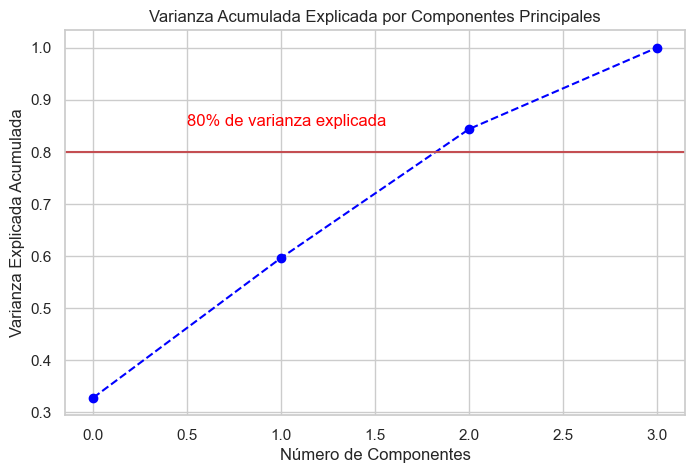

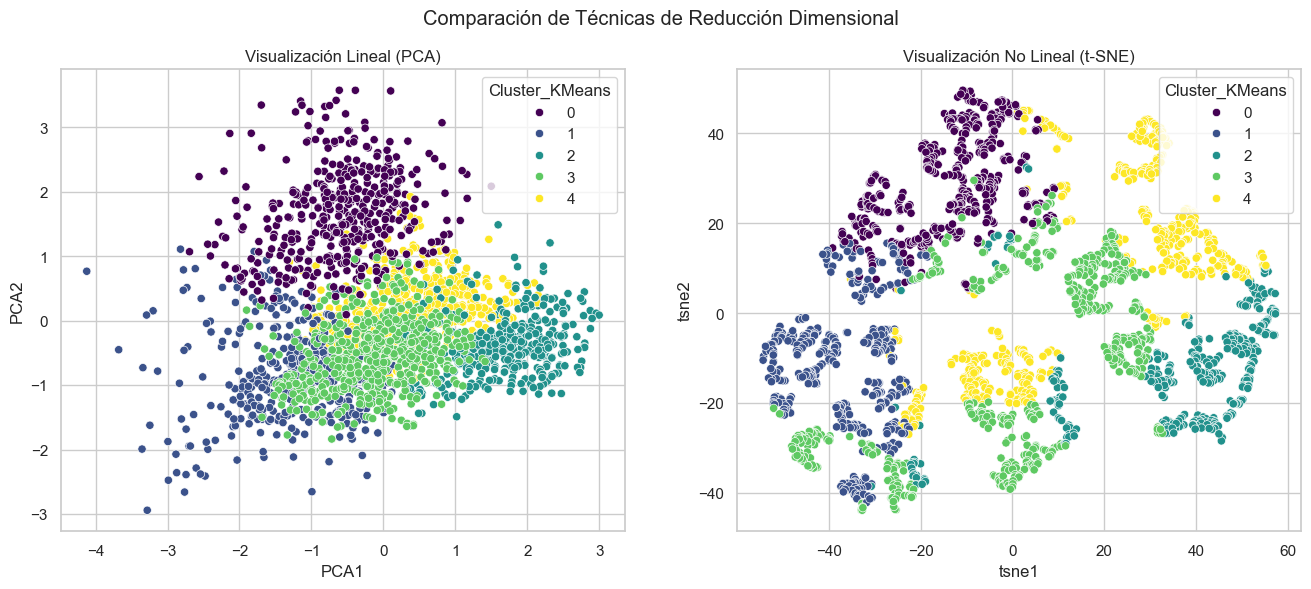

In [5]:
from sklearn.decomposition import PCA

# Analizamos cuánta información (varianza) retiene cada componente
pca_full = PCA().fit(data_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', color='blue')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.axhline(y=0.80, color='r', linestyle='-') # Umbral del 80%
plt.text(0.5, 0.85, '80% de varianza explicada', color = 'red', fontsize=12)
plt.show()

# Aplicamos PCA con 2 componentes para la visualización final
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(data_scaled)
df_final['PCA1'] = X_pca[:, 0]
df_final['PCA2'] = X_pca[:, 1]
df_final.head()  # Verificamos que las nuevas columnas se hayan agregado correctamente

from sklearn.manifold import TSNE

# Ejecutamos t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(data_scaled)
df_final['tsne1'] = X_tsne[:, 0]
df_final['tsne2'] = X_tsne[:, 1]

# Creación de la gráfica comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PCA
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_KMeans', data=df_final, palette='viridis', ax=ax1)
ax1.set_title('Visualización Lineal (PCA)')

# Gráfico t-SNE
sns.scatterplot(x='tsne1', y='tsne2', hue='Cluster_KMeans', data=df_final, palette='viridis', ax=ax2)
ax2.set_title('Visualización No Lineal (t-SNE)')

plt.suptitle('Comparación de Técnicas de Reducción Dimensional')
plt.show()

#### 5.1 Evaluación de las Técnicas
* **PCA:** Nos muestra que con solo 2 componentes logramos explicar una gran parte de la varianza (revisar gráfico de codo). Es eficiente y rápido, ideal si quisiéramos usar estos datos para un modelo supervisado posterior.
* **t-SNE:** Revela agrupaciones mucho más claras y "separadas". Al ser una técnica no lineal, captura mejor la estructura de los segmentos de clientes, confirmando que los grupos identificados por K-Means tienen una cohesión real en el espacio multidimensional.

**Conclusión:** Para la presentación final al cliente, utilizaremos la gráfica de **t-SNE**, ya que comunica de manera más intuitiva la separación de los segmentos de mercado.